## Evaluate a custom Presidio Analyzer using the Presidio Evaluator framework

This notebook demonstrates how to evaluate a Presidio instance using the presidio-evaluator framework. It builds upon [example 4](4_Evaluate_Presidio_Analyzer.ipynb), with changes to the `PresidioAnalyzer` instance to improve detection accuracy. For more information on customizing the Presidio Analyzer, see the [Presidio Analyzer documentation](https://microsoft.github.io/presidio/analyzer/) or this [tutorial](https://microsoft.github.io/presidio/tutorial/).

Steps:
1. Load dataset from file
2. Simple dataset statistics
3. Define the AnalyzerEngine object (and its parameters)
4. Interactive entity mapping with EntityMappingHelper
5. Set up the Evaluator object
6. Run experiment
7. Evaluate results
8. Error analysis

In [2]:
# install presidio evaluator via pip if not yet installed

#!pip install presidio-evaluator
#!pip install "presidio-analyzer[transformers]"

In [3]:
import json
import warnings
from collections import Counter
from pathlib import Path
from pprint import pprint

warnings.filterwarnings("ignore")

import pandas as pd
from presidio_analyzer import (
    AnalyzerEngine,
    Pattern,
    PatternRecognizer,
    RecognizerRegistry,
)
from presidio_analyzer.context_aware_enhancers import LemmaContextAwareEnhancer
from presidio_analyzer.nlp_engine import NerModelConfiguration, TransformersNlpEngine

from presidio_evaluator import InputSample
from presidio_evaluator.entity_mapping import EntityMappingHelper
from presidio_evaluator.evaluation import ModelError, Plotter, SpanEvaluator
from presidio_evaluator.experiment_tracking import get_experiment_tracker
from presidio_evaluator.models import PresidioAnalyzerWrapper

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

%reload_ext autoreload
%autoreload 2
%matplotlib inline

## 1. Load dataset from file

In [4]:
dataset_name = "synth_dataset_v2.json"
dataset = InputSample.read_dataset_json(Path(Path.cwd().parent, "data", dataset_name))

print(len(dataset))

tokenizing input:   0%|          | 0/1500 [00:00<?, ?it/s]

loading model en_core_web_sm


tokenizing input: 100%|██████████| 1500/1500 [00:06<00:00, 229.81it/s]

1500


This dataset was auto generated. See more info here [Synthetic data generation](1_Generate_data.ipynb).

In [5]:
def get_entity_counts(dataset: list[InputSample]) -> dict:
    """Return a dictionary with counter per entity type."""
    entity_counter = Counter()
    for sample in dataset:
        for tag in sample.tags:
            entity_counter[tag] += 1
    return entity_counter

## 2. Simple dataset statistics

In [6]:
entity_counts = get_entity_counts(dataset)
print("Count per entity:")
pprint(entity_counts.most_common(), compact=True)

print(
    "\nMin and max number of tokens in dataset: "
    f"Min: {min([len(sample.tokens) for sample in dataset])}, "
    f"Max: {max([len(sample.tokens) for sample in dataset])}"
)

print(
    f"Min and max sentence length in dataset: "
    f"Min: {min([len(sample.full_text) for sample in dataset])}, "
    f"Max: {max([len(sample.full_text) for sample in dataset])}"
)

Count per entity:
[('O', 19626), ('STREET_ADDRESS', 3071), ('PERSON', 1369), ('GPE', 521),
 ('ORGANIZATION', 504), ('PHONE_NUMBER', 350), ('DATE_TIME', 219),
 ('TITLE', 142), ('CREDIT_CARD', 136), ('US_SSN', 80), ('AGE', 74), ('NRP', 55),
 ('ZIP_CODE', 50), ('EMAIL_ADDRESS', 49), ('DOMAIN_NAME', 37),
 ('IP_ADDRESS', 22), ('IBAN_CODE', 21), ('US_DRIVER_LICENSE', 9)]

Min and max number of tokens in dataset: Min: 3, Max: 78
Min and max sentence length in dataset: Min: 9, Max: 407


## 3. Define the AnalyzerEngine object 
In this case, we customize the AnalyzerEngine to use a different NER model, some custom recognizers and the context aware enhancer.

### 3.1 Set up the NlpEngine and Hugging Face NER Recognizer
The NLP engine uses spaCy for text processing (lemmas, tokens, etc.). The Hugging Face model is added as a direct recognizer (HuggingFaceNerRecognizer) instead of being part of the NLP engine. This approach gives better control over model predictions.

In [7]:
# Map OpenMed model entities to Presidio entities
mapping = {
    # Personal Info - Names & Demographics
    "first_name": "PERSON",
    "last_name": "PERSON",
    "age": "AGE",
    "gender": "GENDER",
    "date_of_birth": "DATE_TIME",
    "blood_type": "BLOOD_TYPE",
    "occupation": "OCCUPATION",
    "education_level": "EDUCATION_LEVEL",
    "employment_status": "EMPLOYMENT_STATUS",
    "language": "LOCATION",
    "race_ethnicity": "ETHNICITY",
    "sexuality": "SEXUALITY",
    "political_view": "ORGANIZATION",
    "religious_belief": "ORGANIZATION",
    "biometric_identifier": "ID",
    "pin": "ID",
    # Identifiers (20+ types)
    "account_number": "ID",
    "customer_id": "ID",
    "employee_id": "ID",
    "unique_id": "ID",
    "bank_routing_number": "US_BANK_NUMBER",
    "swift_bic": "SWIFT_CODE",
    "certificate_license_number": "MEDICAL_LICENSE",
    "medical_record_number": "MEDICAL_LICENSE",
    "health_plan_beneficiary_number": "ID",
    "credit_debit_card": "CREDIT_CARD",
    "cvv": "CVV",
    "ssn": "US_SSN",
    "tax_id": "ID",
    "license_plate": "LICENSE_PLATE",
    "vehicle_identifier": "ID",
    "mac_address": "ID",
    "device_identifier": "ID",
    # Authentication & Security
    "password": "PASSWORD",
    "user_name": "USER_NAME",
    # Contact Info (4 types)
    "email": "EMAIL_ADDRESS",
    "phone_number": "PHONE_NUMBER",
    "fax_number": "PHONE_NUMBER",
    "url": "URL",
    # Location (6 types)
    "city": "LOCATION",
    "country": "LOCATION",
    "county": "LOCATION",
    "state": "LOCATION",
    "street_address": "LOCATION",
    "coordinate": "LOCATION",
    "postcode": "ZIP_CODE",
    # Network Info
    "ipv4": "IP_ADDRESS",
    "ipv6": "IP_ADDRESS",
    # Temporal (3 types)
    "date": "DATE_TIME",
    "date_time": "DATE_TIME",
    "time": "DATE_TIME",
    # Organization (1 type)
    "company_name": "ORGANIZATION",
}

models = [
    {
        "lang_code": "en",
        "model_name": {
            "spacy": "en_core_web_sm",  # use a small spaCy model for lemmas, tokens etc.
            "transformers": "OpenMed/OpenMed-PII-BioClinicalModern-Large-395M-v1",
        },
    }
]

ner_config = NerModelConfiguration(
    model_to_presidio_entity_mapping=mapping, aggregation_strategy="simple"
)

# Create the NLP engine without entity mapping (will be handled by EntityMappingHelper)
nlp_engine = TransformersNlpEngine(models=models, ner_model_configuration=ner_config)
nlp_engine.load()

Device set to use cpu


### 3.2 Set up the relevant recognizers
Add and remove recognizers to fit the dataset in hand. 
Removing all the recognizers that don't map to entities in our dataset.

In [8]:
def get_titles_recognizer():
    titles_recognizer = PatternRecognizer(
        deny_list=["Mr.", "Mrs.", "Ms.", "Miss", "Dr.", "Prof."],
        supported_entity="TITLE",
        name="TitlesRecognizer",
    )
    return titles_recognizer


def get_years_recognizer():
    years_recognizer = PatternRecognizer(
        patterns=[Pattern("YEAR", r"\b(19|20)\d{2}\b", score=0.1)],
        supported_entity="DATE_TIME",
        name="YearsRecognizer",
        context=["year", "at", "date", "in", "on"],
    )
    return years_recognizer


def get_age_recognizer():
    weak_regex = r"\b(110|[1-9]?[0-9])\b"
    age_pattern = Pattern(name="age (very weak)", regex=weak_regex, score=0.01)
    age_recognizer = PatternRecognizer(
        supported_entity="AGE",
        patterns=[age_pattern],
        name="AgeRecognizer",
        context=["month", "old", "turn", "age", "y/o"],
    )
    return age_recognizer


# Create Recognizer Registry
registry = RecognizerRegistry()
registry.load_predefined_recognizers(nlp_engine=nlp_engine)

# Add custom pattern recognizers
registry.add_recognizer(get_titles_recognizer())
registry.add_recognizer(get_years_recognizer())
registry.add_recognizer(get_age_recognizer())

# Remove unnecessary recognizers from presidio
unnecessary = [
    "NhsRecognizer",
    "UkNinoRecognizer",
    "SgFinRecognizer",
    "AuAbnRecognizer",
    "AuAcnRecognizer",
    "AuTfnRecognizer",
    "AuMedicareRecognizer",
    "InPanRecognizer",
    "InAadhaarRecognizer",
    "InVehicleRegistrationRecognizer",
    "InPassportRecognizer",
    "InVoterRecognizer",
    "UsLicenseRecognizer",
    "CryptoRecognizer",
    "SpacyRecognizer",
]

for rec in unnecessary:
    registry.remove_recognizer(rec)

### 3.3 Configure the context mechanism
Configure the `LemmaContextAawareEnhancer` which uses surrounding words to increase confidence in detection

In [9]:
# Set up the context aware enhancer
context_enhancer = LemmaContextAwareEnhancer(
    context_prefix_count=10, context_suffix_count=10
)

### 3.4 Create the AnalyzerEngine object

In [10]:
# Set up the engine, loads the NLP module (spaCy model by default)
# and other PII recognizers
analyzer_engine = AnalyzerEngine(
    nlp_engine=nlp_engine,
    context_aware_enhancer=context_enhancer,
    registry=registry,
    default_score_threshold=0.3,
)

# analyzer_engine = AnalyzerEngine()

pprint("Supported entities for English:")
pprint(analyzer_engine.get_supported_entities("en"), compact=True)

print("\nLoaded recognizers for English:")
pprint(
    [
        rec.name
        for rec in analyzer_engine.registry.get_recognizers("en", all_fields=True)
    ],
    compact=True,
)

print("\nLoaded Context Aware Enhancer:")
print(analyzer_engine.context_aware_enhancer.__class__.__name__)
pprint(json.dumps(analyzer_engine.context_aware_enhancer.__dict__), compact=True)


print("\nLoaded NER models:")
pprint(analyzer_engine.nlp_engine.models)

'Supported entities for English:'
['EMPLOYMENT_STATUS', 'ID', 'URL', 'SWIFT_CODE', 'CREDIT_CARD', 'AGE',
 'SEXUALITY', 'MAC_ADDRESS', 'IP_ADDRESS', 'CVV', 'PASSWORD', 'LICENSE_PLATE',
 'LOCATION', 'DATE_TIME', 'GENDER', 'USER_NAME', 'US_PASSPORT',
 'MEDICAL_LICENSE', 'US_ITIN', 'EMAIL_ADDRESS', 'US_BANK_NUMBER',
 'EDUCATION_LEVEL', 'BLOOD_TYPE', 'US_SSN', 'ZIP_CODE', 'PERSON', 'TITLE',
 'PHONE_NUMBER', 'OCCUPATION', 'ETHNICITY', 'IBAN_CODE', 'ORGANIZATION']

Loaded recognizers for English:
['CreditCardRecognizer', 'UsBankRecognizer', 'UsItinRecognizer',
 'UsPassportRecognizer', 'UsSsnRecognizer', 'DateRecognizer', 'EmailRecognizer',
 'IbanRecognizer', 'IpRecognizer', 'MedicalLicenseRecognizer',
 'MacAddressRecognizer', 'PhoneRecognizer', 'UrlRecognizer',
 'TransformersRecognizer', 'TitlesRecognizer', 'YearsRecognizer',
 'AgeRecognizer']

Loaded Context Aware Enhancer:
LemmaContextAwareEnhancer
('{"context_similarity_factor": 0.35, "min_score_with_context_similarity": '
 '0.4, "context_

In [11]:
# Test Analyzer
text = "Yesterday in Mt. Sinai AP: Dana Silver, 79 years old female was complaining of stomach pain. Her ID is 154555"
res = analyzer_engine.analyze(text=text, language="en", return_decision_process=True)
for result in res:
    print(
        f"\nEntity: {result.entity_type}, Text: {text[result.start : result.end]}\n\nAnalysis explanation:"
    )
    pprint(result.analysis_explanation)


Entity: PERSON, Text: Dana

Analysis explanation:
{'recognizer': 'TransformersRecognizer', 'pattern_name': None, 'pattern': None, 'original_score': 0.9997214674949646, 'score': 0.9997214674949646, 'textual_explanation': "Identified as PERSON by Transformers's Named Entity Recognition", 'score_context_improvement': 0, 'supportive_context_word': '', 'validation_result': None, 'regex_flags': None}

Entity: PERSON, Text: Silver

Analysis explanation:
{'recognizer': 'TransformersRecognizer', 'pattern_name': None, 'pattern': None, 'original_score': 0.9988800883293152, 'score': 0.9988800883293152, 'textual_explanation': "Identified as PERSON by Transformers's Named Entity Recognition", 'score_context_improvement': 0, 'supportive_context_word': '', 'validation_result': None, 'regex_flags': None}

Entity: AGE, Text: 79

Analysis explanation:
{'recognizer': 'TransformersRecognizer', 'pattern_name': None, 'pattern': None, 'original_score': 0.99313884973526, 'score': 0.99313884973526, 'textual_ex

## 4. Interactive Entity Mapping

Use `EntityMappingHelper` to automatically align dataset entities with model entities.

**Why entity mapping?** The dataset may use entity labels like `STREET_ADDRESS` or `GPE` (geopolitical entity), while the model outputs `LOCATION`. To properly evaluate the model, we need to map dataset entities to their corresponding model entities. The `EntityMappingHelper` automatically detects both sets of entities and suggests mappings, with the ability to manually adjust them.



In [12]:
# Create the helper - automatically detects entities and suggests mappings
helper = EntityMappingHelper(dataset=dataset, model=analyzer_engine, language="en")

# Review the suggested mapping
helper.review_mapping()

Dataset Entity,→ Model Entity,Samples,Confidence
✓ US_DRIVER_LICENSE,US_PASSPORT,5,0.82
✓ AGE,AGE,74,1.00
✓ CREDIT_CARD,CREDIT_CARD,136,1.00
✓ DATE_TIME,DATE_TIME,119,1.00
✓ DOMAIN_NAME,URL,37,1.00
✓ EMAIL_ADDRESS,EMAIL_ADDRESS,49,1.00
✓ GPE,LOCATION,325,1.00
✓ IBAN_CODE,IBAN_CODE,21,1.00
✓ IP_ADDRESS,IP_ADDRESS,14,1.00
✓ NRP,ORGANIZATION,55,1.00


In [ ]:
# Map ZIP_CODE to itself since we create a recognizer for it
helper.set_mapping("ZIP_CODE", "ZIP_CODE")

# Exclude entities not present in the dataset to avoid false positives
# Get all entities supported by the model
all_model_entities = set(analyzer_engine.get_supported_entities("en"))

# Get the entities that are mapped from the dataset
dataset_mapped_entities = set(helper.get_mapping().values())

# Entities to exclude = all model entities NOT in the dataset mapping
entities_to_exclude = list(all_model_entities - dataset_mapped_entities)

print(f"Excluding {len(entities_to_exclude)} entities not in dataset:")
print(sorted(entities_to_exclude))

# Exclude these entities from evaluation (they'll be treated as non-PII)
helper.exclude_model_entities(entities_to_exclude)

✓ Mapping set: ZIP_CODE → ZIP_CODE
Excluding 17 entities not in dataset:
['BLOOD_TYPE', 'CVV', 'EDUCATION_LEVEL', 'EMPLOYMENT_STATUS', 'ETHNICITY', 'GENDER', 'ID', 'LICENSE_PLATE', 'MAC_ADDRESS', 'MEDICAL_LICENSE', 'OCCUPATION', 'PASSWORD', 'SEXUALITY', 'SWIFT_CODE', 'USER_NAME', 'US_BANK_NUMBER', 'US_ITIN']
✓ Excluded 17 model entity(ies)


In [14]:
# Get final mappings and filtered dataset
entities_mapping = helper.get_mapping()
model_entities_to_use = helper.get_model_entities_to_use()
dataset = helper.get_filtered_dataset()

print("=== Final Configuration ===")
print(f"\nDataset → Model mapping: {len(entities_mapping)} entities")
pprint(entities_mapping, compact=True)

print(f"\nModel entities to evaluate: {sorted(model_entities_to_use)}")
print(f"Filtered dataset: {len(dataset)} samples")

print("\n✓ Ready for evaluation")

=== Final Configuration ===

Dataset → Model mapping: 17 entities
{'AGE': 'AGE',
 'CREDIT_CARD': 'CREDIT_CARD',
 'DATE_TIME': 'DATE_TIME',
 'DOMAIN_NAME': 'URL',
 'EMAIL_ADDRESS': 'EMAIL_ADDRESS',
 'GPE': 'LOCATION',
 'IBAN_CODE': 'IBAN_CODE',
 'IP_ADDRESS': 'IP_ADDRESS',
 'NRP': 'ORGANIZATION',
 'ORGANIZATION': 'ORGANIZATION',
 'PERSON': 'PERSON',
 'PHONE_NUMBER': 'PHONE_NUMBER',
 'STREET_ADDRESS': 'LOCATION',
 'TITLE': 'TITLE',
 'US_DRIVER_LICENSE': 'US_PASSPORT',
 'US_SSN': 'US_SSN',
 'ZIP_CODE': 'ZIP_CODE'}

Model entities to evaluate: ['AGE', 'CREDIT_CARD', 'DATE_TIME', 'EMAIL_ADDRESS', 'IBAN_CODE', 'IP_ADDRESS', 'LOCATION', 'ORGANIZATION', 'PERSON', 'PHONE_NUMBER', 'TITLE', 'URL', 'US_PASSPORT', 'US_SSN', 'ZIP_CODE']
Filtered dataset: 1387 samples

✓ Ready for evaluation


## 5. Set up the Evaluator object
In case of a mismatch between the model's entities and the dataset's entities, 
you can use only entities which exist in the dataset or include all model predictions. Change the `USE_FILTERED_ENTITIES` flag to select the desired behavior.
* True is better when you want fair comparison with dataset labels
* False is better for fully leveraging the model's capabilities which is likely going to increase recall (but may decrease precision due to the prediction of untagged entities in the dataset)

In [ ]:
USE_FILTERED_ENTITIES = False

# Set up the experiment tracker
experiment = get_experiment_tracker()

# Wrap the analyzer
wrapped_analyzer = PresidioAnalyzerWrapper(
    analyzer_engine=analyzer_engine,
    score_threshold=analyzer_engine.default_score_threshold,
    language="en",
)

# Create the evaluator with entity mapping and entities to keep
evaluator = SpanEvaluator(
    model=wrapped_analyzer,
    entity_mapping=entities_mapping,
    entities_to_keep=model_entities_to_use if USE_FILTERED_ENTITIES else None,
    iou_threshold=0.75,
)

# Track experiment parameters
params = {"dataset_name": dataset_name, "model_name": evaluator.model.name}
params.update(evaluator.model.to_log())
experiment.log_parameters(params)
experiment.log_dataset_hash(dataset)
experiment.log_parameter("entity_mappings", json.dumps(entities_mapping))

--------
Entities supported by this Presidio Analyzer instance:
EMPLOYMENT_STATUS, ID, URL, SWIFT_CODE, CREDIT_CARD, AGE, SEXUALITY, MAC_ADDRESS, IP_ADDRESS, CVV, PASSWORD, LICENSE_PLATE, LOCATION, DATE_TIME, GENDER, USER_NAME, US_PASSPORT, MEDICAL_LICENSE, US_ITIN, EMAIL_ADDRESS, US_BANK_NUMBER, EDUCATION_LEVEL, BLOOD_TYPE, US_SSN, ZIP_CODE, PERSON, TITLE, PHONE_NUMBER, OCCUPATION, ETHNICITY, IBAN_CODE, ORGANIZATION


## 6. Run experiment

In [16]:
%%time

## Run experiment

evaluation_results = evaluator.evaluate_all(dataset)
results = evaluator.calculate_score(evaluation_results)

# Track experiment results
experiment.log_metrics(results.to_log())
entities, confmatrix = results.to_confusion_matrix()
experiment.log_confusion_matrix(matrix=confmatrix, labels=entities)

# end experiment
experiment.end()

# Note that the experiment params and metrics are saved locally

saving experiment data to /Users/omrimendels/Documents/github/presidio-research/notebooks/experiment_20260301-235134.json
CPU times: user 2min 4s, sys: 1min 5s, total: 3min 9s
Wall time: 2min 10s


## 7. Evaluate results

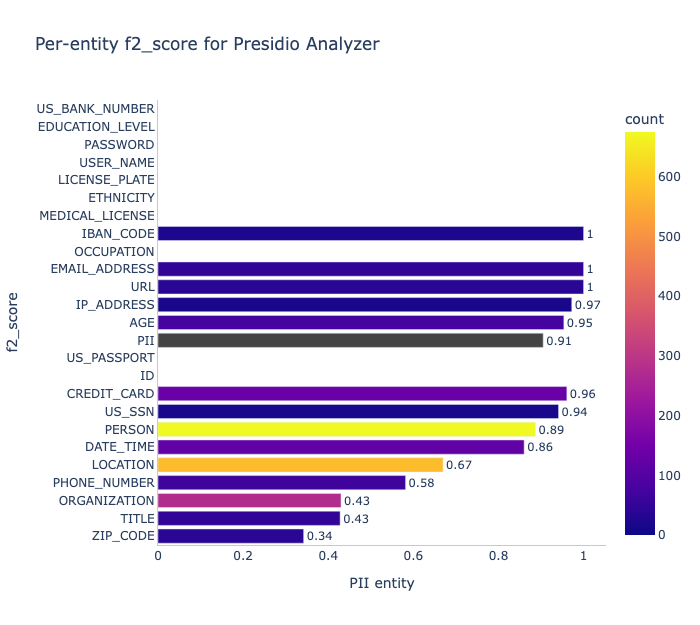

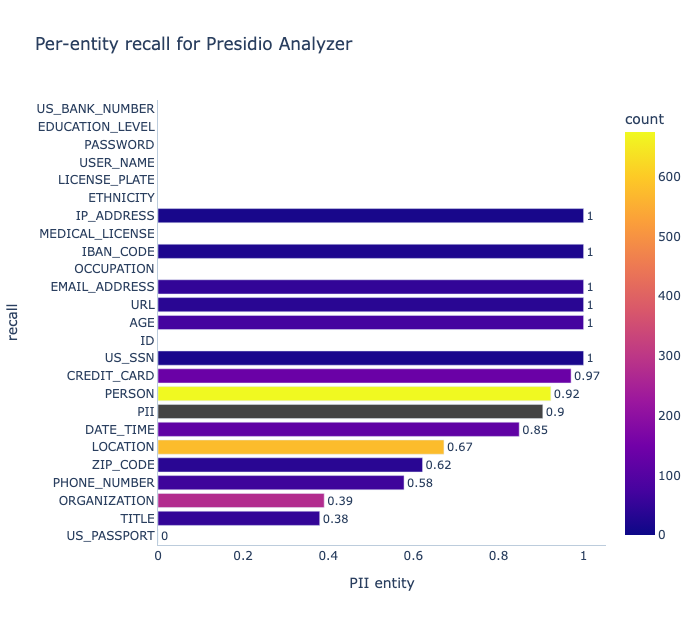

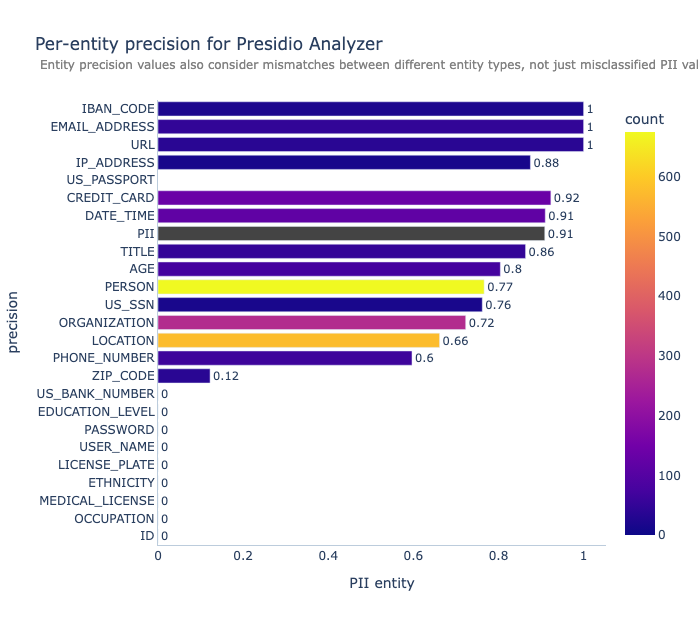

In [ ]:
# Plot output
plotter = Plotter(
    results=results, model_name=evaluator.model.name, display_mode="interactive", beta=2
)
plotter.plot_scores()

In [18]:
pprint(
    {
        "PII F": results.pii_f,
        "PII recall": results.pii_recall,
        "PII precision": results.pii_precision,
    }
)

{'PII F': 0.9050915909418724,
 'PII precision': 0.9087617668356264,
 'PII recall': 0.904178674351585}


## 8. Error analysis

The `ModelError` class groups similar errors together, finding all the false positive and false negative predictions where the model's behavior is consistent. 

This can help in detecting patterns in the model's performance, such as:
- Consistent labeling of specific words or patterns  
- Systematic overprediction or underprediction

**Note:** All errors are displayed using the **mapped model entity types** (e.g., `LOCATION`, `PERSON`) rather than the original dataset entity types (e.g., `STREET_ADDRESS`, `GPE`). This ensures consistency with how the model was evaluated.

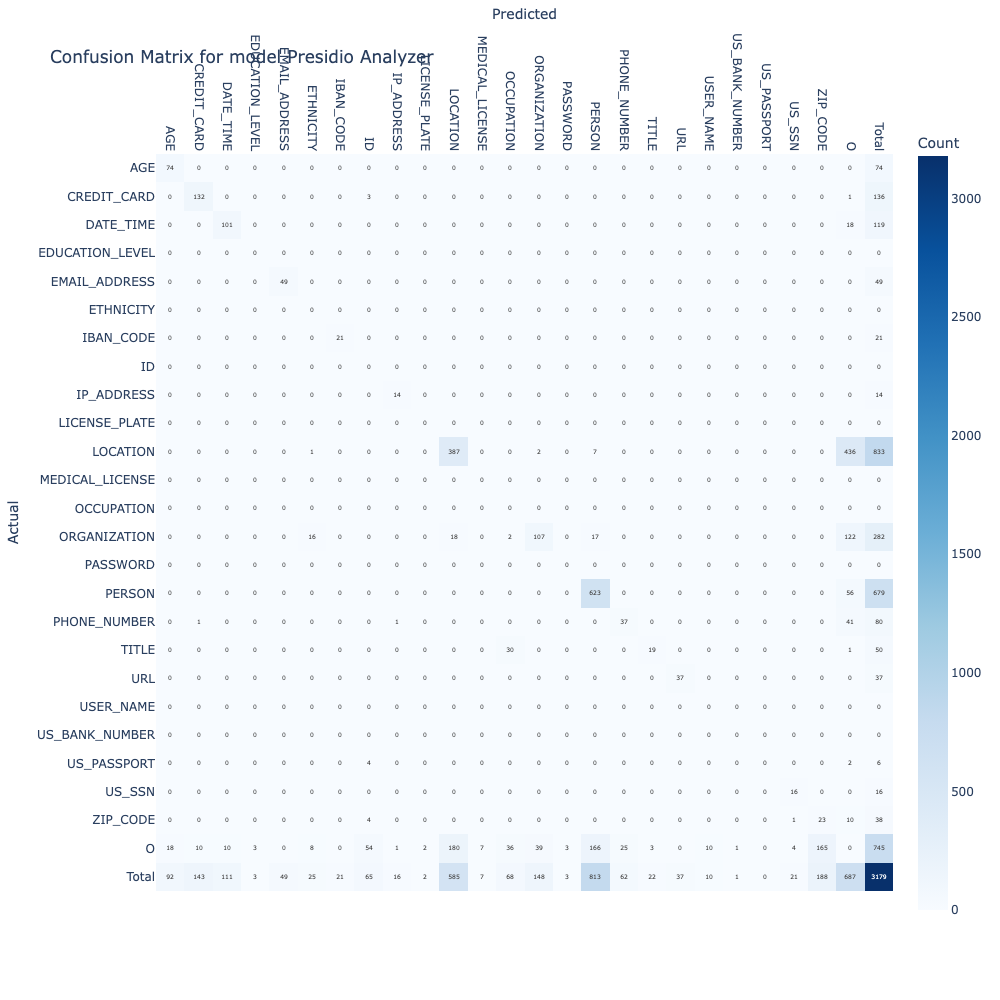

In [19]:
plotter.plot_confusion_matrix(entities=entities, confmatrix=confmatrix)

In [20]:
# plotter.plot_most_common_tokens()

### 8a. False positives
#### Most common false positive tokens:

In [21]:
ModelError.most_common_fp_tokens(results.model_errors)

Most common false positive tokens:
[('royal', 11),
 ('engineers', 10),
 ('salesperson', 9),
 ('8 16', 9),
 ('breakfast', 9),
 ('greenlander', 9),
 ('fuse', 8),
 ('zombie', 8),
 ('executives', 7),
 ('baroque', 6)]
---------------
Example sentence with each FP token:
	- Royal (`royal` pred as PERSON)
	- engineers (`engineers` pred as OCCUPATION)
	- salesperson (`salesperson` pred as OCCUPATION)
	- 8 16 (`8 16` pred as AGE)
	- breakfast (`breakfast` pred as DATE_TIME)
	- Greenlander (`greenlander` pred as ETHNICITY)
	- Fuse (`fuse` pred as ORGANIZATION)
	- Zombie (`zombie` pred as OCCUPATION)
	- executives (`executives` pred as OCCUPATION)
	- baroque (`baroque` pred as ID)


[('royal', 11),
 ('engineers', 10),
 ('salesperson', 9),
 ('8 16', 9),
 ('breakfast', 9),
 ('greenlander', 9),
 ('fuse', 8),
 ('zombie', 8),
 ('executives', 7),
 ('baroque', 6)]

#### More FP analysis

In [22]:
fps_df = ModelError.get_fps_dataframe(results.model_errors, entity="AGE")
fps_df[["full_text", "token", "annotation", "prediction"]].head(20)

,full_text,token,annotation,prediction
0,501(c)3,501(c)3,O,AGE
1,8 16,8 16,O,AGE
2,92,92,O,AGE
3,8 16,8 16,O,AGE
4,8 16,8 16,O,AGE
5,501(c)3,501(c)3,O,AGE
6,501(c)3,501(c)3,O,AGE
7,501(c)3,501(c)3,O,AGE
8,66,66,O,AGE
9,8 16,8 16,O,AGE


### 8b. False negatives (FN)

#### Most common false negative examples + a few samples with FN

In [23]:
ModelError.most_common_fn_tokens(results.model_errors, n=15)

Most common false negative tokens:
[('estonia', 7),
 ('czech', 7),
 ('polish', 6),
 ('spanish', 6),
 ('american', 6),
 ('greenlander', 6),
 ('tuesday', 4),
 ('english', 4),
 ('russian', 4),
 ('thursday', 4),
 ('saturday', 3),
 ('monday', 3),
 ('owens duran oneal', 3),
 ('allianz', 3),
 ('persint', 2)]
---------------
Example sentence with each FN token:
	- Estonia (`estonia` annotated as LOCATION)
	- Czech (`czech` annotated as ORGANIZATION)
	- Polish (`polish` annotated as ORGANIZATION)
	- Spanish (`spanish` annotated as ORGANIZATION)
	- American (`american` annotated as ORGANIZATION)
	- Greenlander (`greenlander` annotated as ORGANIZATION)
	- Tuesday (`tuesday` annotated as DATE_TIME)
	- English (`english` annotated as ORGANIZATION)
	- Russian (`russian` annotated as ORGANIZATION)
	- Thursday (`thursday` annotated as DATE_TIME)
	- Saturday (`saturday` annotated as DATE_TIME)
	- Monday (`monday` annotated as DATE_TIME)
	- owens , duran and oneal (`owens duran oneal` annotated as ORGAN

[('estonia', 7),
 ('czech', 7),
 ('polish', 6),
 ('spanish', 6),
 ('american', 6),
 ('greenlander', 6),
 ('tuesday', 4),
 ('english', 4),
 ('russian', 4),
 ('thursday', 4),
 ('saturday', 3),
 ('monday', 3),
 ('owens duran oneal', 3),
 ('allianz', 3),
 ('persint', 2)]

#### More FN analysis

In [24]:
fns_df = ModelError.get_fns_dataframe(results.model_errors, entity="PERSON")

In [25]:
fns_df[["full_text", "token", "annotation", "prediction"]].head(20)

,full_text,token,annotation,prediction
0,Christiansen,christiansen,PERSON,O
1,Jensen,jensen,PERSON,O
2,Kaczmarek,kaczmarek,PERSON,O
3,Bonifacy Kaczmarek,bonifacy kaczmarek,PERSON,O
4,Meza,meza,PERSON,O
5,Zoe Young,zoe young,PERSON,O
6,Ella H. Snider,ella h. snider,PERSON,O
7,Ella H. Snider,ella h. snider,PERSON,O
8,Gyala Antall,gyala antall,PERSON,O
9,Gyala Antall,gyala antall,PERSON,O
